# **DIABETES PREDICTION OF 2023**

## **0. Library import**


In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.config import (
    LOG_DIR, RAW_DATA_DIR, TRAINING_DIR,
    BEST_ACCURACY_MODEL_SCALER_FILE_PATH, BEST_ACCURACY_MODEL_FILE_PATH, 
    BEST_F1_MODEL_SCALER_FILE_PATH, BEST_F1_MODEL_FILE_PATH, 
    BEST_RECALL_MODEL_SCALER_FILE_PATH, BEST_RECALL_MODEL_FILE_PATH, BEST_PRECISION_MODEL_FILE_PATH
)
from src.utils import load_data
from src.data import BrfssDataLoader, BrfssDataCleaner
from src.visualization import (
    plot_diabetes_distribution_by_indicators, 
    plot_correlation_matrix, 
    plot_class_distribution,
    plot_comprehensive_diabetes_analysis, 
    plot_additional_features_analysis, 
)
from src.features import DiabetesFeatureEngineering
from src.models import DiabetesXGBoostClassifier, DiabetesRandomForest

## **1. Download and load dataset**

In [3]:
# Download and extract BRFSS 2023 dataset
brfss_dataloader = BrfssDataLoader(
    logger_name="data_pipeline.data_cleaner", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
brfss_dataloader.load_data(
    urls=["https://www.cdc.gov/brfss/annual_data/2023/files/LLCP2023XPT.zip"],
    filenames=["brfss_2023.XPT"]
)

2025-09-28 15:02:02,923 - [data_pipeline.data_cleaner] - INFO - BrfssDataLoader initialized successfully
2025-09-28 15:02:02,925 - [data_pipeline.data_cleaner] - INFO - Starting data loading process...
2025-09-28 15:02:02,928 - [data_pipeline.data_cleaner] - INFO - Processing: LLCP2023XPT.zip
2025-09-28 15:02:02,929 - [data_pipeline.data_cleaner] - INFO - LLCP2023XPT.zip not found locally. Downloading...
2025-09-28 15:02:02,930 - [data_pipeline.data_cleaner] - INFO - Navigating to URL: https://www.cdc.gov/brfss/annual_data/2023/files/LLCP2023XPT.zip
2025-09-28 15:02:03,931 - [data_pipeline.data_cleaner] - INFO - Starting download: LLCP2023XPT.zip (91052.56 KB)
LLCP2023XPT.zip: 100%|██████████| 88.9M/88.9M [00:03<00:00, 30.4MB/s]
2025-09-28 15:02:07,008 - [data_pipeline.data_cleaner] - INFO - Downloaded: LLCP2023XPT.zip -> .../data/raw/zip/LLCP2023XPT.zip
2025-09-28 15:02:07,010 - [data_pipeline.data_cleaner] - INFO - Attempting to extract zip file: .../data/raw/zip/LLCP2023XPT.zip
2025

In [4]:
# Filter necessary features
brfss_data_cleaner = BrfssDataCleaner(
    logger_name="data_pipeline.data_cleaner", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
cleaned_df = brfss_data_cleaner.clean(file_path=f"{RAW_DATA_DIR}/brfss_2023.XPT", dropna=True)

2025-09-28 15:02:09,642 - [data_pipeline.data_cleaner] - INFO - BrfssDataCleaner initialized successfully
2025-09-28 15:02:09,643 - [data_pipeline.data_cleaner] - INFO - Clean features from .../data/raw/brfss_2023.XPT
2025-09-28 15:02:35,481 - [data_pipeline.data_cleaner] - INFO - Column 'Diabetes' has 5 missing values.
2025-09-28 15:02:35,483 - [data_pipeline.data_cleaner] - INFO - Column 'HighChol' has 51812 missing values.
2025-09-28 15:02:35,483 - [data_pipeline.data_cleaner] - INFO - Column 'BMI' has 40535 missing values.
2025-09-28 15:02:35,484 - [data_pipeline.data_cleaner] - INFO - Column 'Smoker' has 19674 missing values.
2025-09-28 15:02:35,484 - [data_pipeline.data_cleaner] - INFO - Column 'Stroke' has 4 missing values.
2025-09-28 15:02:35,485 - [data_pipeline.data_cleaner] - INFO - Column 'HeartDiseaseorAttack' has 4585 missing values.
2025-09-28 15:02:35,486 - [data_pipeline.data_cleaner] - INFO - Column 'AnyHealthcare' has 5 missing values.
2025-09-28 15:02:35,486 - [data

## **2. Data visualization**

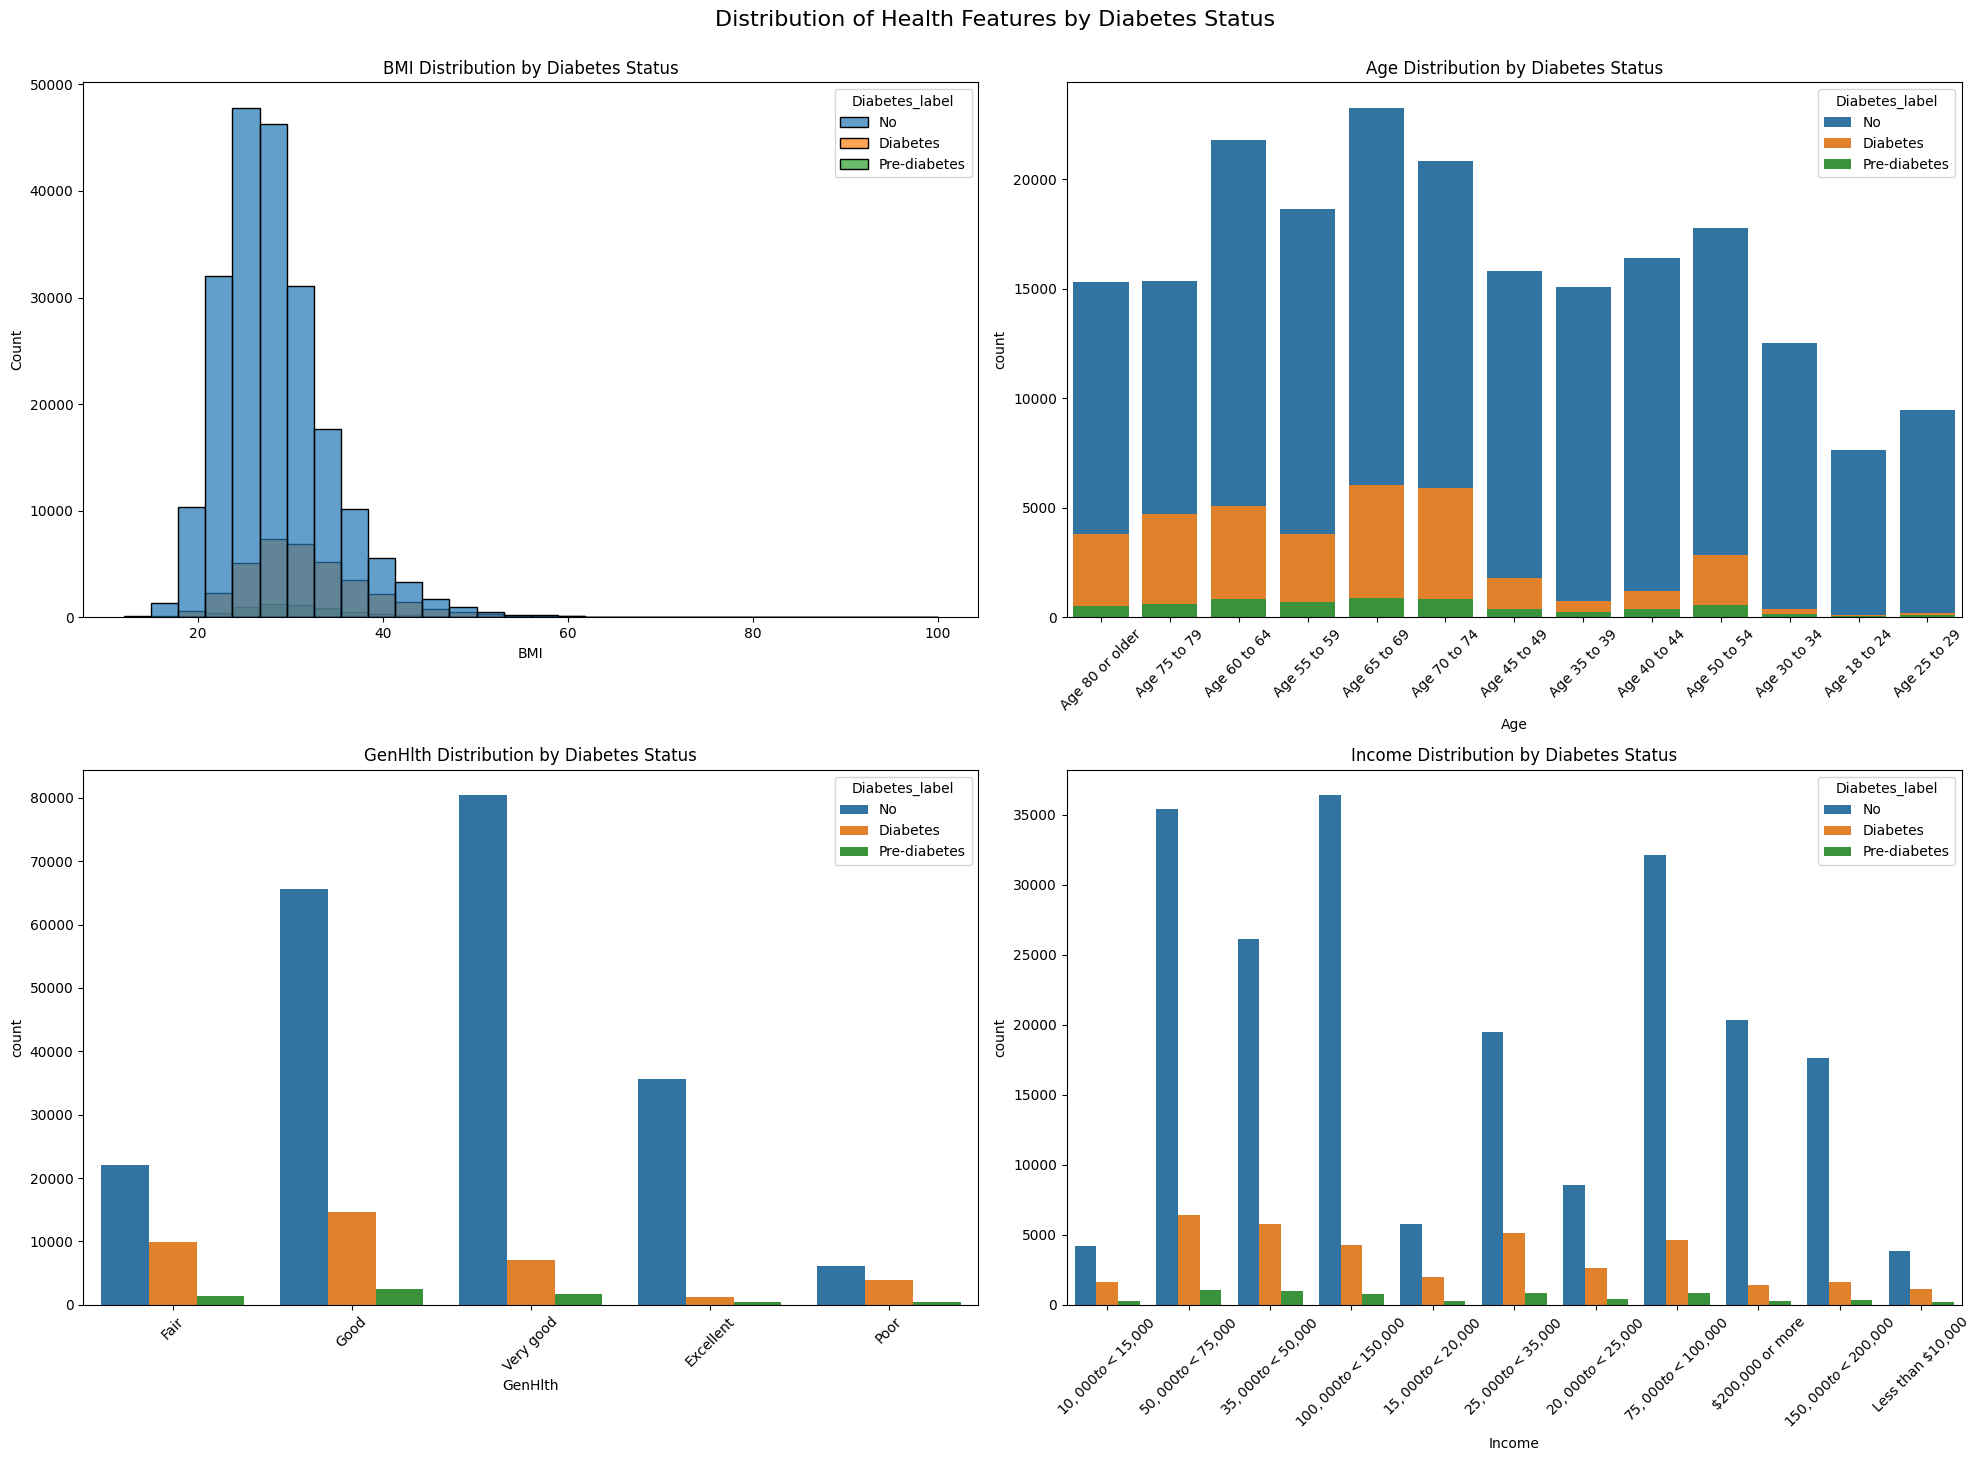

In [5]:
# Assume df is your dataframe with one year of data
features = ['BMI', 'Age', 'GenHlth', 'Income']

# Set up the subplot layout - 2x2 grid for 4 features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()  # Flatten to make indexing easier

# Create mappings based on metadata
mappings = {
    'Age': {
        1.0: "Age 18 to 24",
        2.0: "Age 25 to 29", 
        3.0: "Age 30 to 34",
        4.0: "Age 35 to 39",
        5.0: "Age 40 to 44",
        6.0: "Age 45 to 49",
        7.0: "Age 50 to 54",
        8.0: "Age 55 to 59",
        9.0: "Age 60 to 64",
        10.0: "Age 65 to 69",
        11.0: "Age 70 to 74",
        12.0: "Age 75 to 79",
        13.0: "Age 80 or older"
    },
    'GenHlth': {
        1.0: "Excellent",
        2.0: "Very good", 
        3.0: "Good",
        4.0: "Fair",
        5.0: "Poor"
    },
    'Income': {
        1.0: "Less than $10,000",
        2.0: "$10,000 to < $15,000",
        3.0: "$15,000 to < $20,000", 
        4.0: "$20,000 to < $25,000",
        5.0: "$25,000 to < $35,000",
        6.0: "$35,000 to < $50,000",
        7.0: "$50,000 to < $75,000",
        8.0: "$75,000 to < $100,000",
        9.0: "$100,000 to < $150,000",
        10.0: "$150,000 to < $200,000",
        11.0: "$200,000 or more"
    }
}

# Create Diabetes_label if it doesn't exist
if "Diabetes_label" not in cleaned_df.columns:
    diabetes_mapping = {0: "No", 1: "Pre-diabetes", 2: "Diabetes"}
    cleaned_df["Diabetes_label"] = cleaned_df["Diabetes"].map(diabetes_mapping)

# Create plots for each feature
for i, feature in enumerate(features):
    # Apply mapping if available
    if feature in mappings:
        label_col = f"{feature}_label"
        cleaned_df[label_col] = cleaned_df[feature].map(mappings[feature])
        x_col = label_col
    else:
        x_col = feature
    
    # Draw chart based on feature type
    if feature == 'BMI':
        # BMI is numerical - use histogram
        sns.histplot(data=cleaned_df, x=feature, hue='Diabetes_label',
                     bins=30, ax=axes[i], alpha=0.7)
    elif feature in ['Age', 'GenHlth', 'Income']:
        # Categorical features - use countplot
        if feature == 'Age':
            sns.countplot(data=cleaned_df, x=x_col, hue='Diabetes_label',
                          dodge=False, ax=axes[i], 
                          hue_order=cleaned_df["Diabetes_label"].value_counts(ascending=False).index.tolist())
        else:
            sns.countplot(data=cleaned_df, x=x_col, hue='Diabetes_label',
                          dodge=True, ax=axes[i])
    
    # Set title and labels
    axes[i].set_title(f'{feature} Distribution by Diabetes Status')
    axes[i].set_xlabel(feature)
    
    # Rotate x-axis labels for better readability if needed
    if feature in ['Age', 'GenHlth', 'Income']:
        axes[i].tick_params(axis='x', rotation=45)

# Add overall title
plt.suptitle('Distribution of Health Features by Diabetes Status', fontsize=16, y=0.94)
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


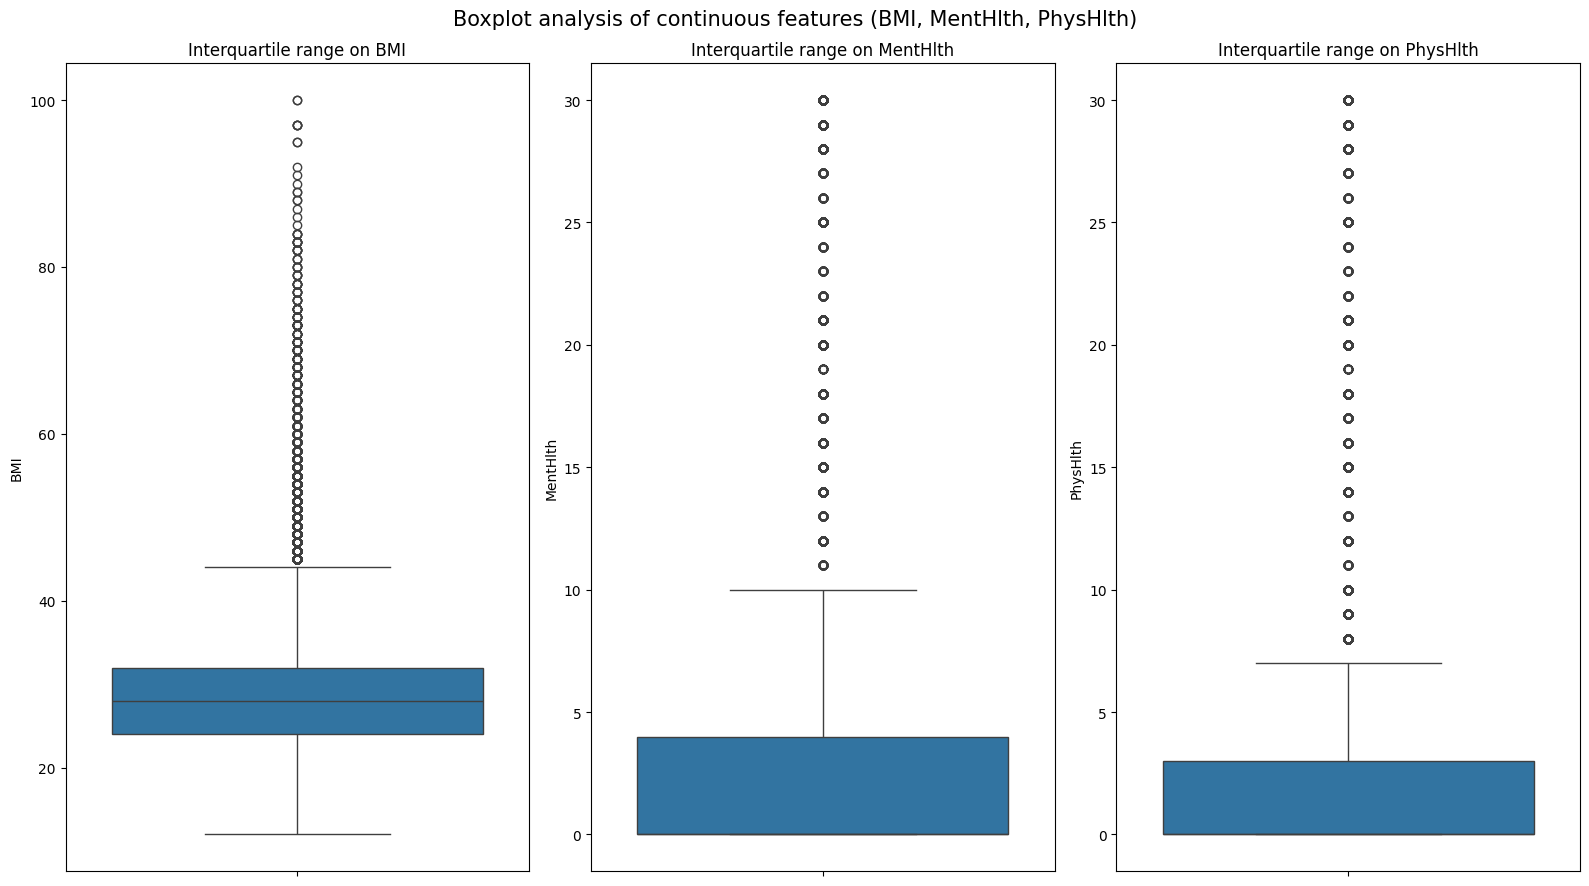

In [6]:
# Draw boxplot to identify outlier
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=cleaned_df, y='BMI', ax=ax[0])
ax[0].set_title('Interquartile range on BMI')

sns.boxplot(data=cleaned_df, y='MentHlth', ax=ax[1])
ax[1].set_title('Interquartile range on MentHlth')

sns.boxplot(data=cleaned_df, y='PhysHlth', ax=ax[2])
ax[2].set_title('Interquartile range on PhysHlth')

plt.suptitle(t="Boxplot analysis of continuous features (BMI, MentHlth, PhysHlth)", fontsize=15)
plt.tight_layout()
plt.show()

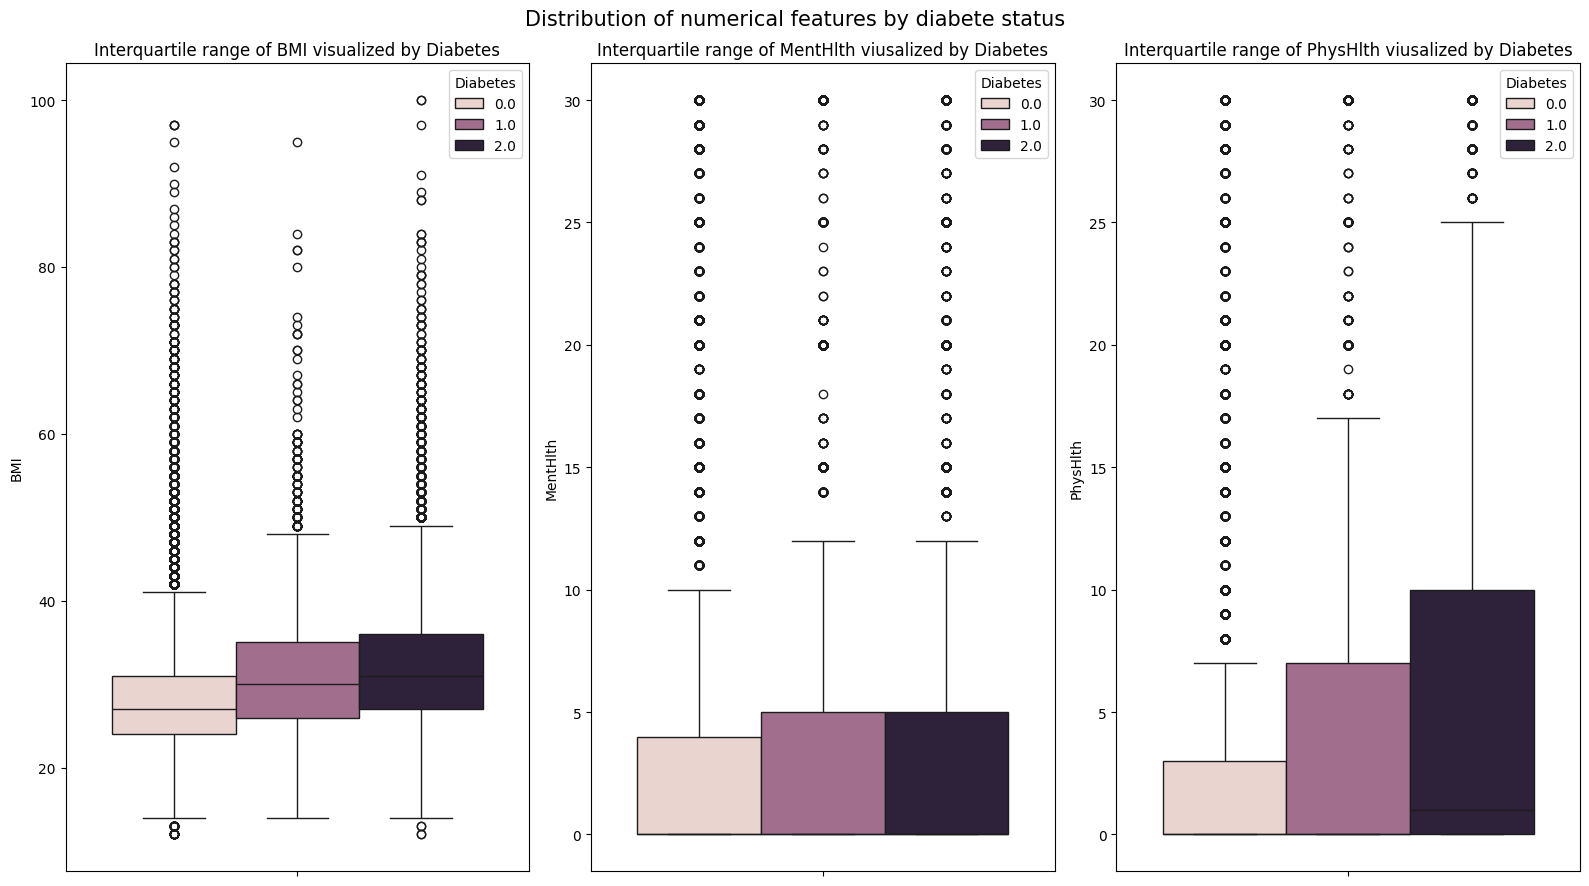

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=cleaned_df, y='BMI', hue='Diabetes', ax=ax[0])
ax[0].set_title('Interquartile range of BMI visualized by Diabetes')

sns.boxplot(data=cleaned_df, y='MentHlth', hue='Diabetes', ax=ax[1])
ax[1].set_title('Interquartile range of MentHlth viusalized by Diabetes')

sns.boxplot(data=cleaned_df, y='PhysHlth', hue='Diabetes', ax=ax[2])
ax[2].set_title('Interquartile range of PhysHlth viusalized by Diabetes')

plt.suptitle(t="Distribution of numerical features by diabete status", fontsize=15)
plt.tight_layout()
plt.show()

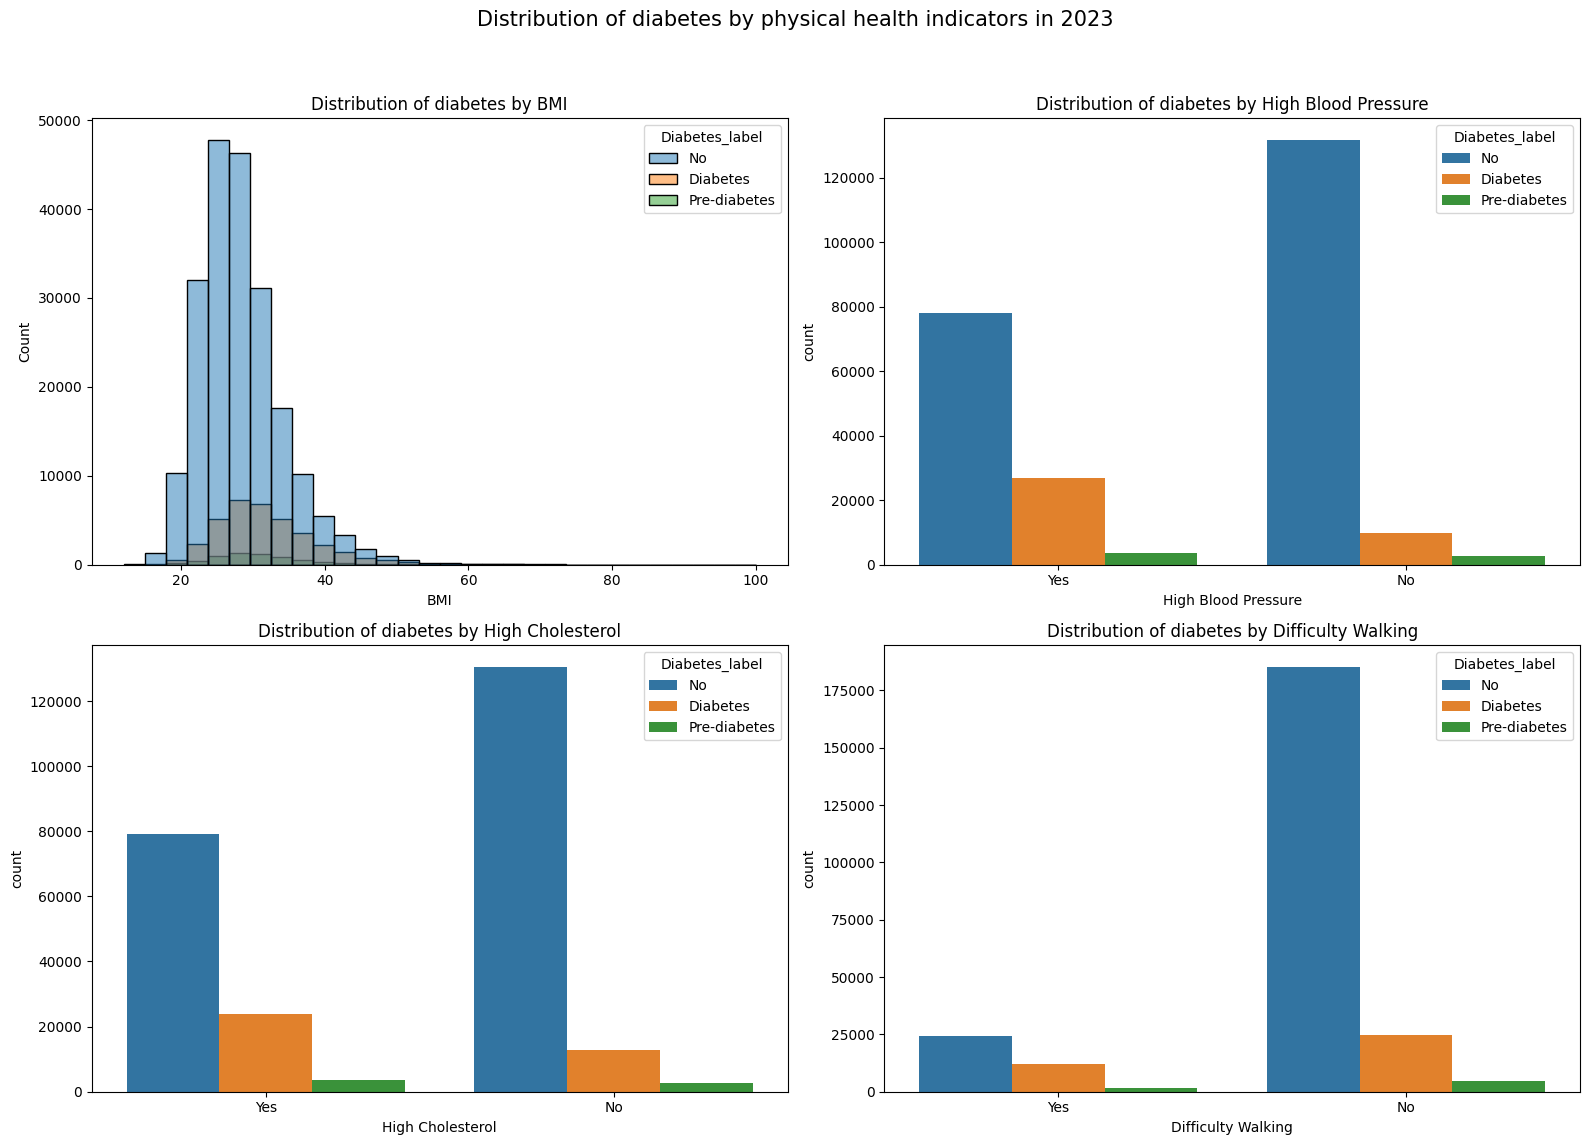

In [8]:
# Distribution of diabetes by physical health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2023,
    title="Distribution of diabetes by physical health indicators"
)

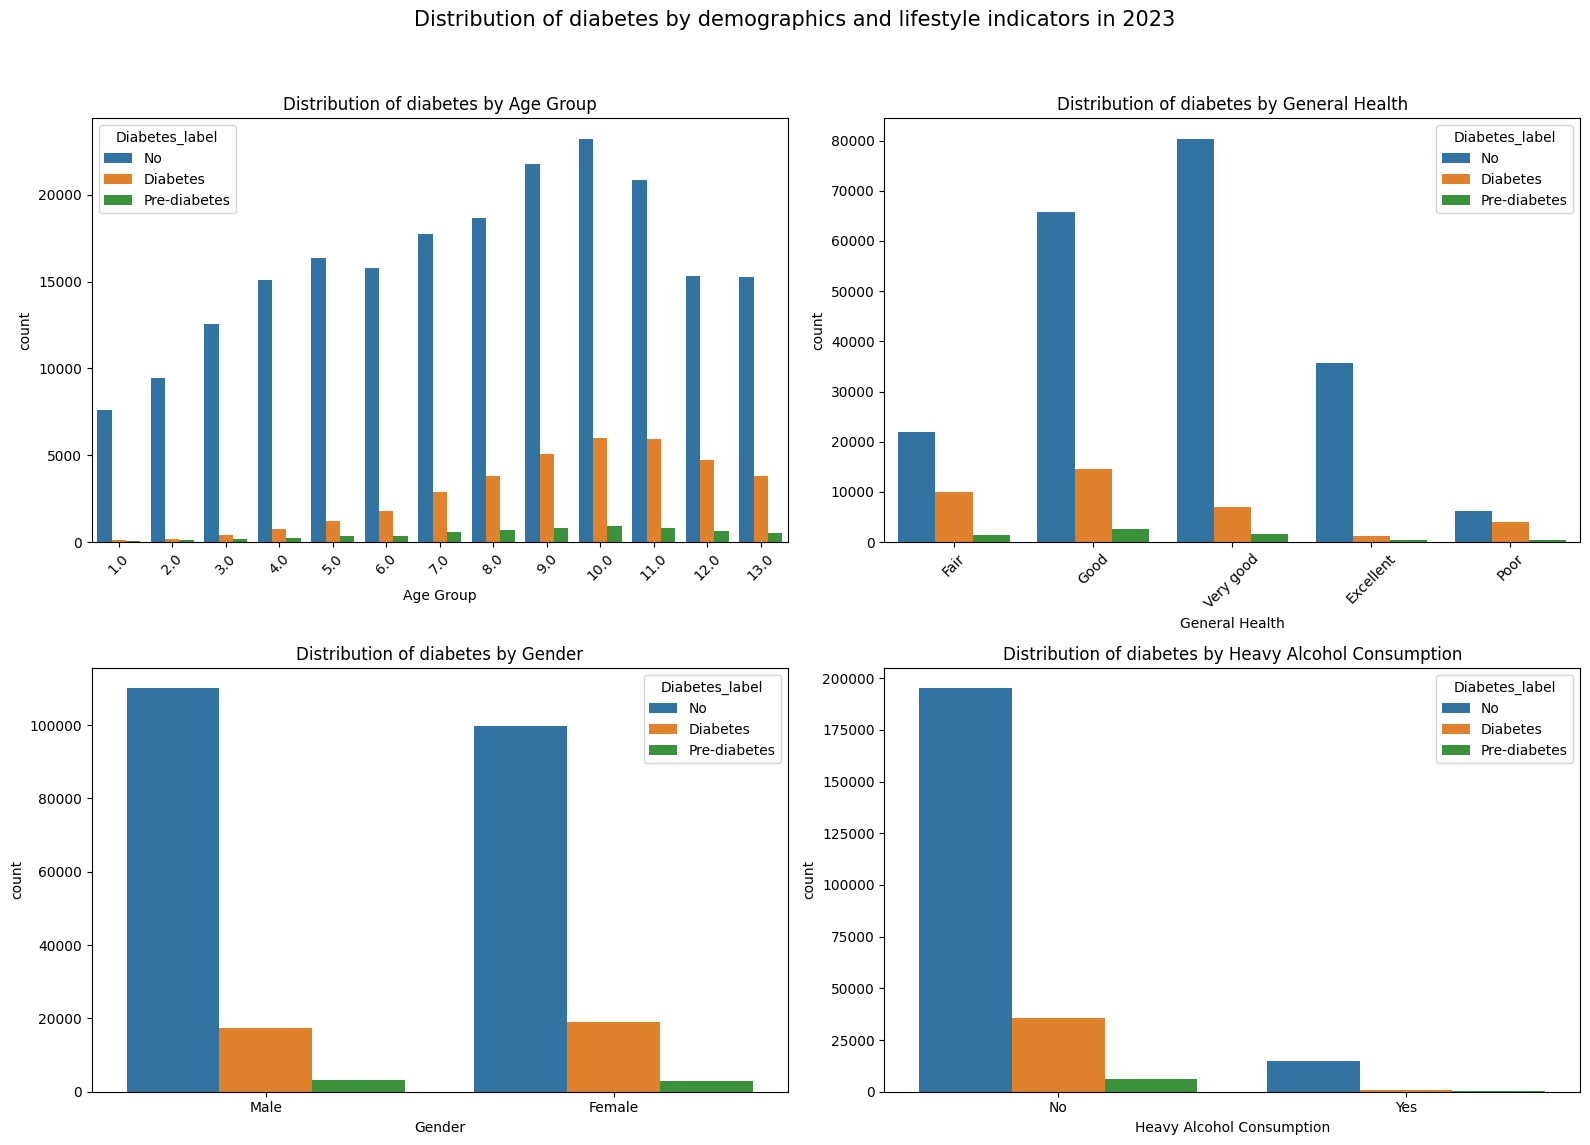

In [9]:
# Distribution of diabetes by demographics and lifestyle indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2023,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

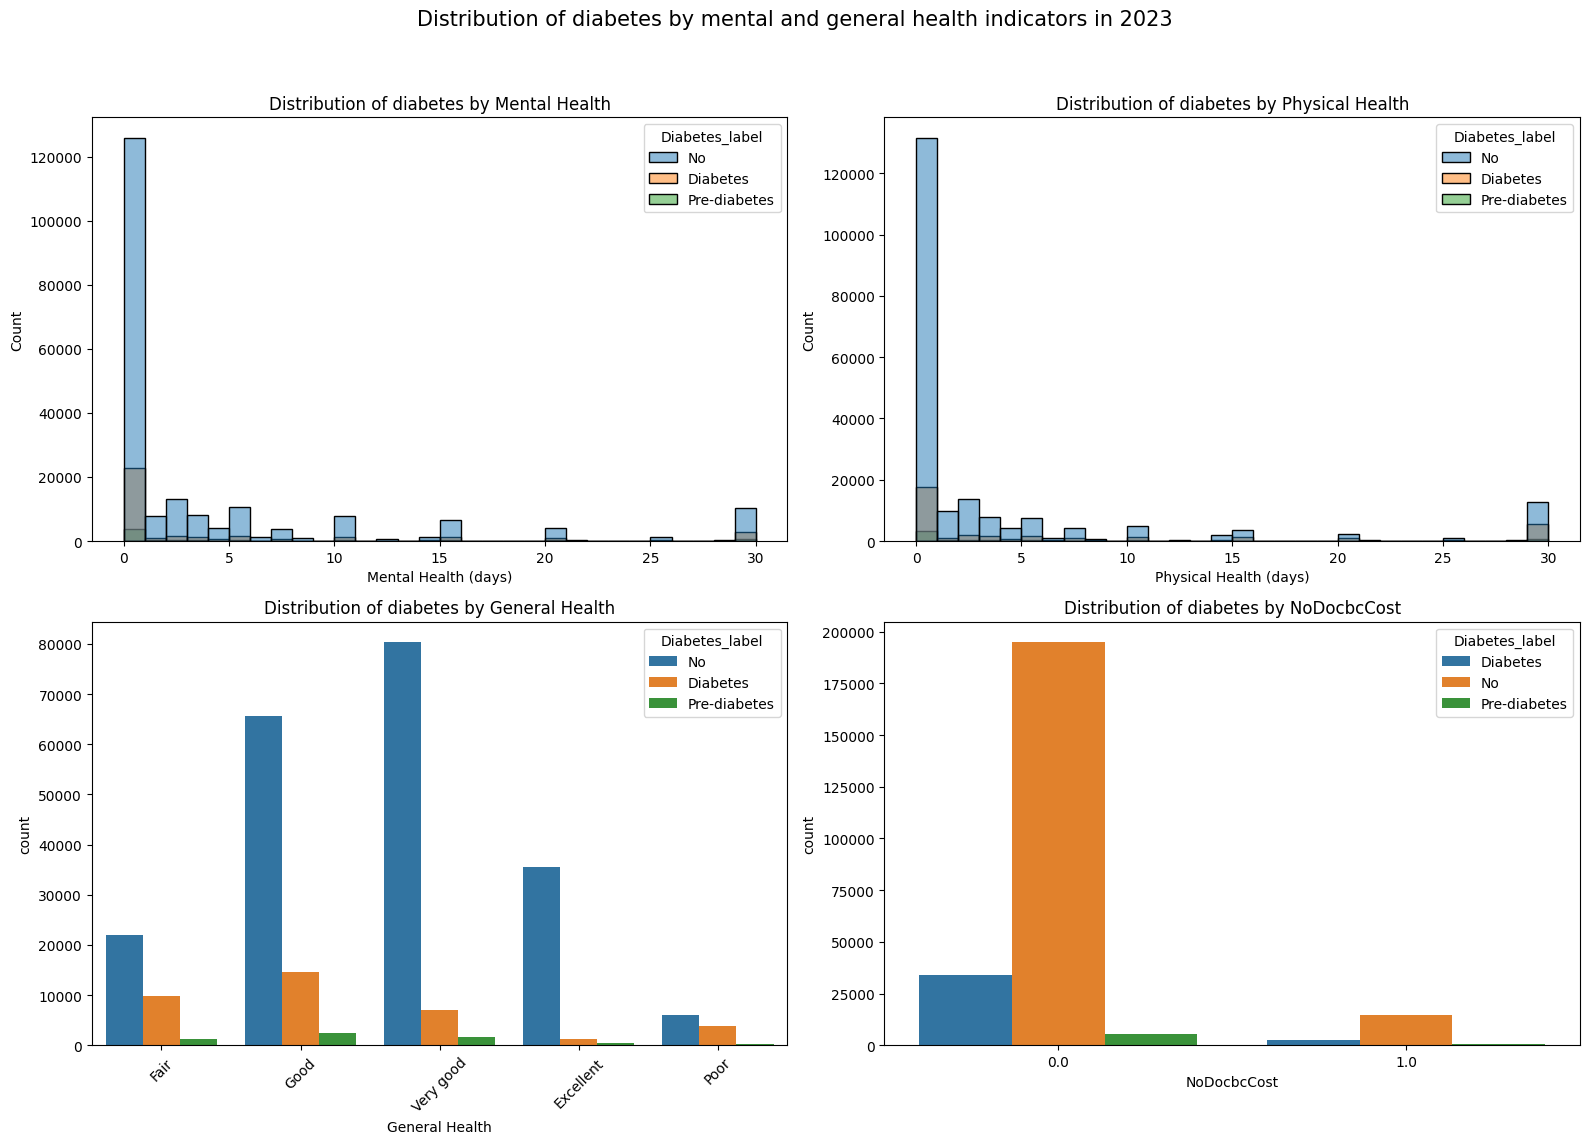

In [10]:
# Distribution of diabetes by mental and general health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2023,
    title="Distribution of diabetes by mental and general health indicators"
)


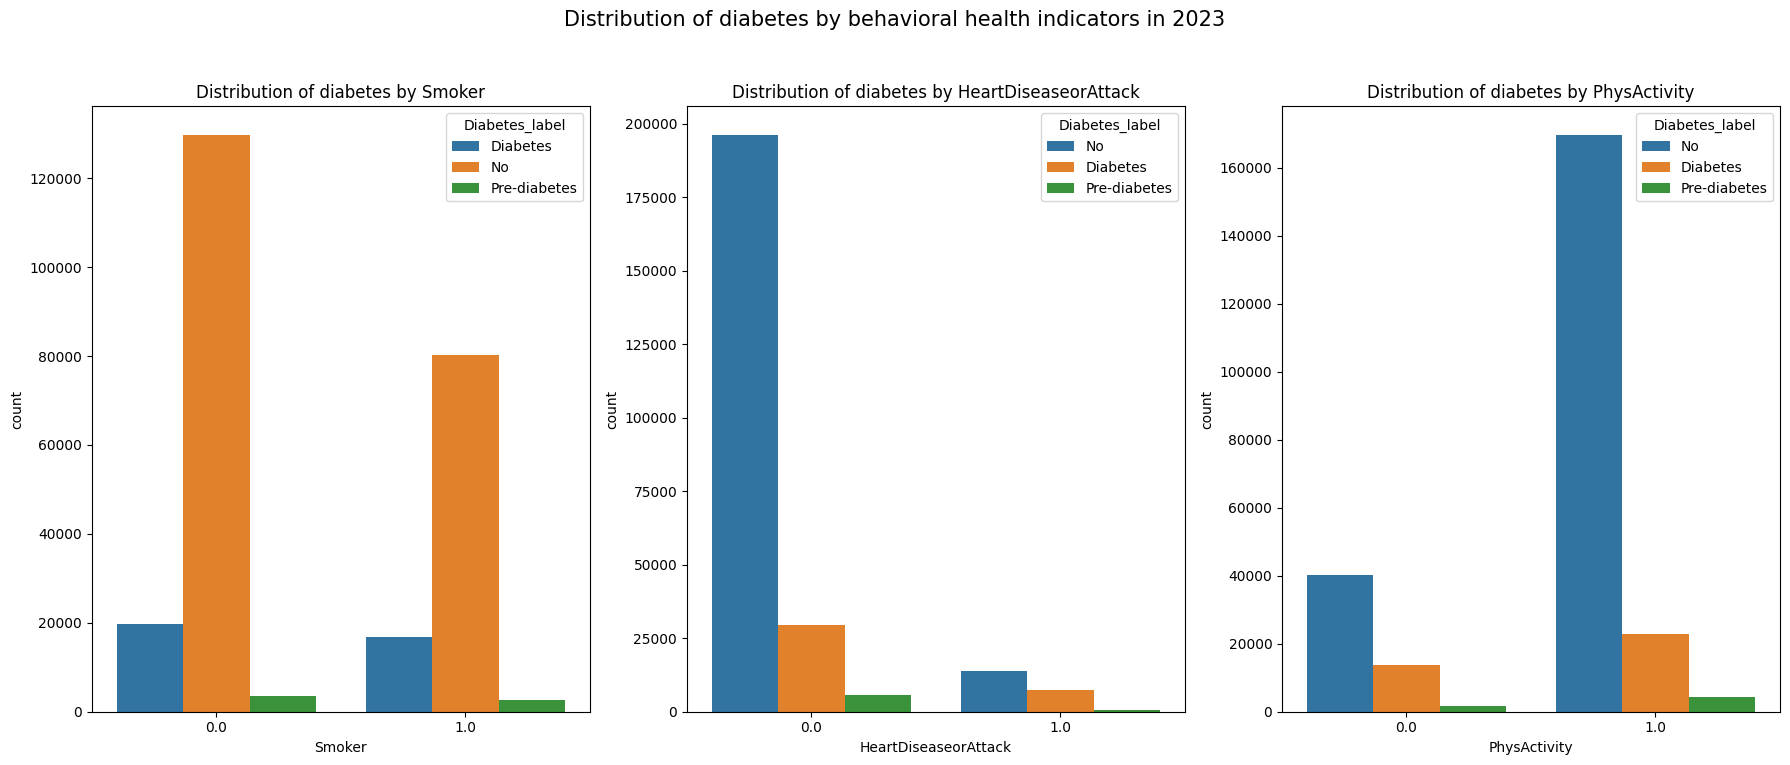

In [11]:
# Distribution of diabetes by behavioral health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2023,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

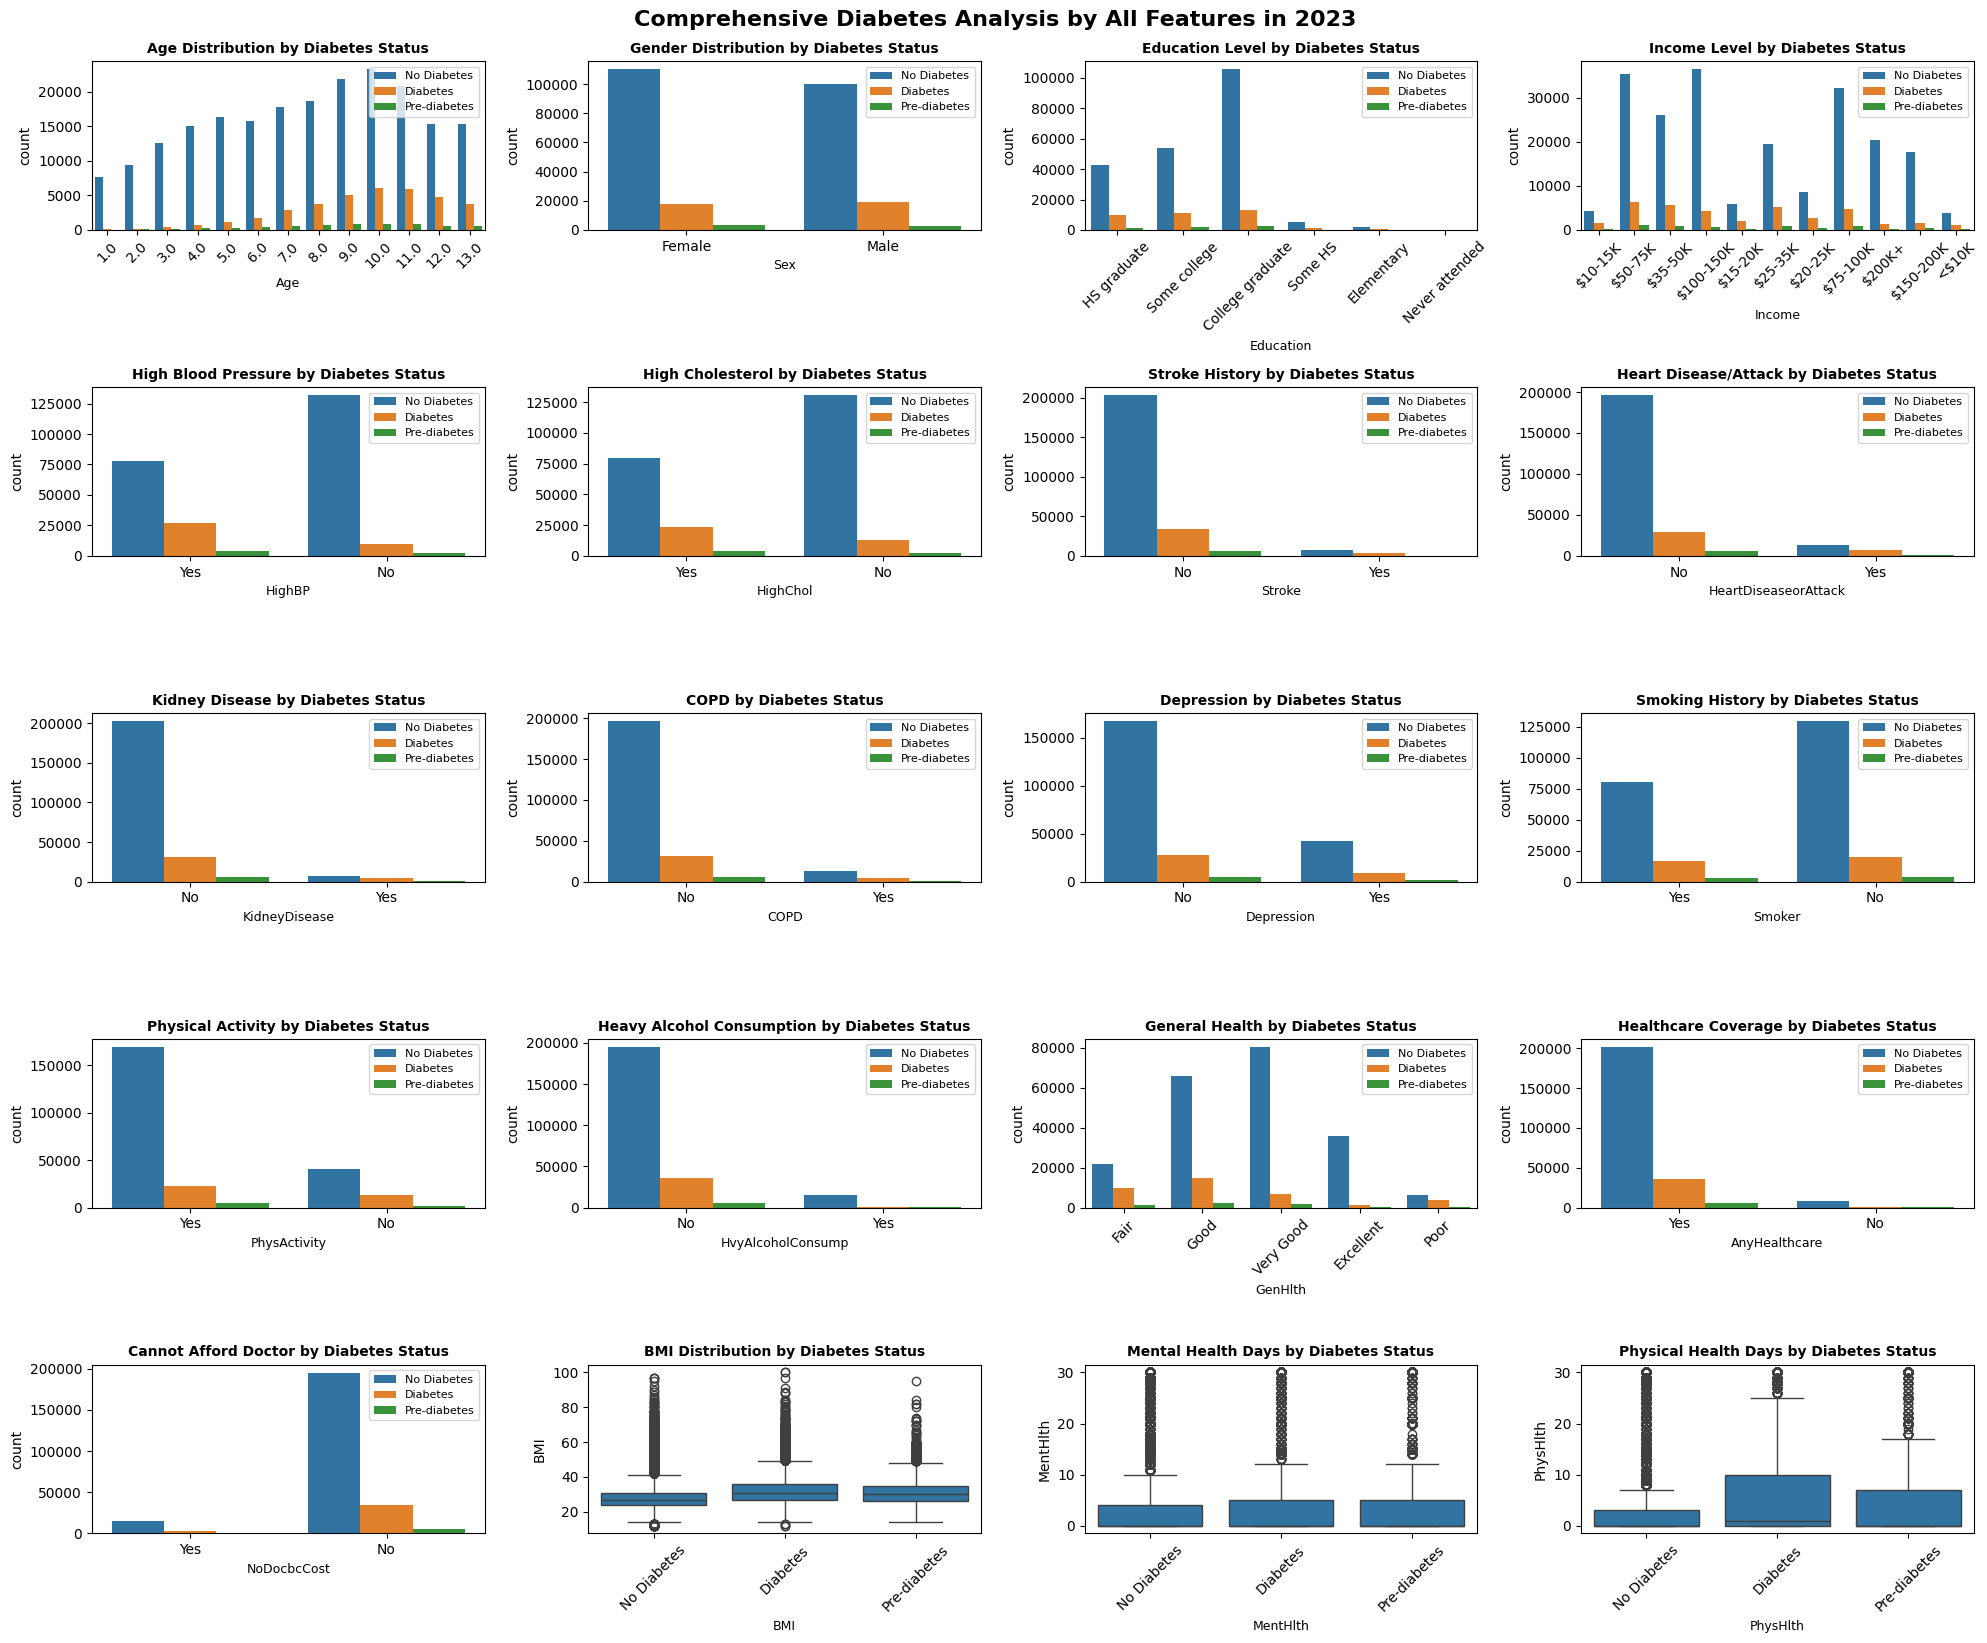

In [12]:
plot_comprehensive_diabetes_analysis(df=cleaned_df, year=2023)

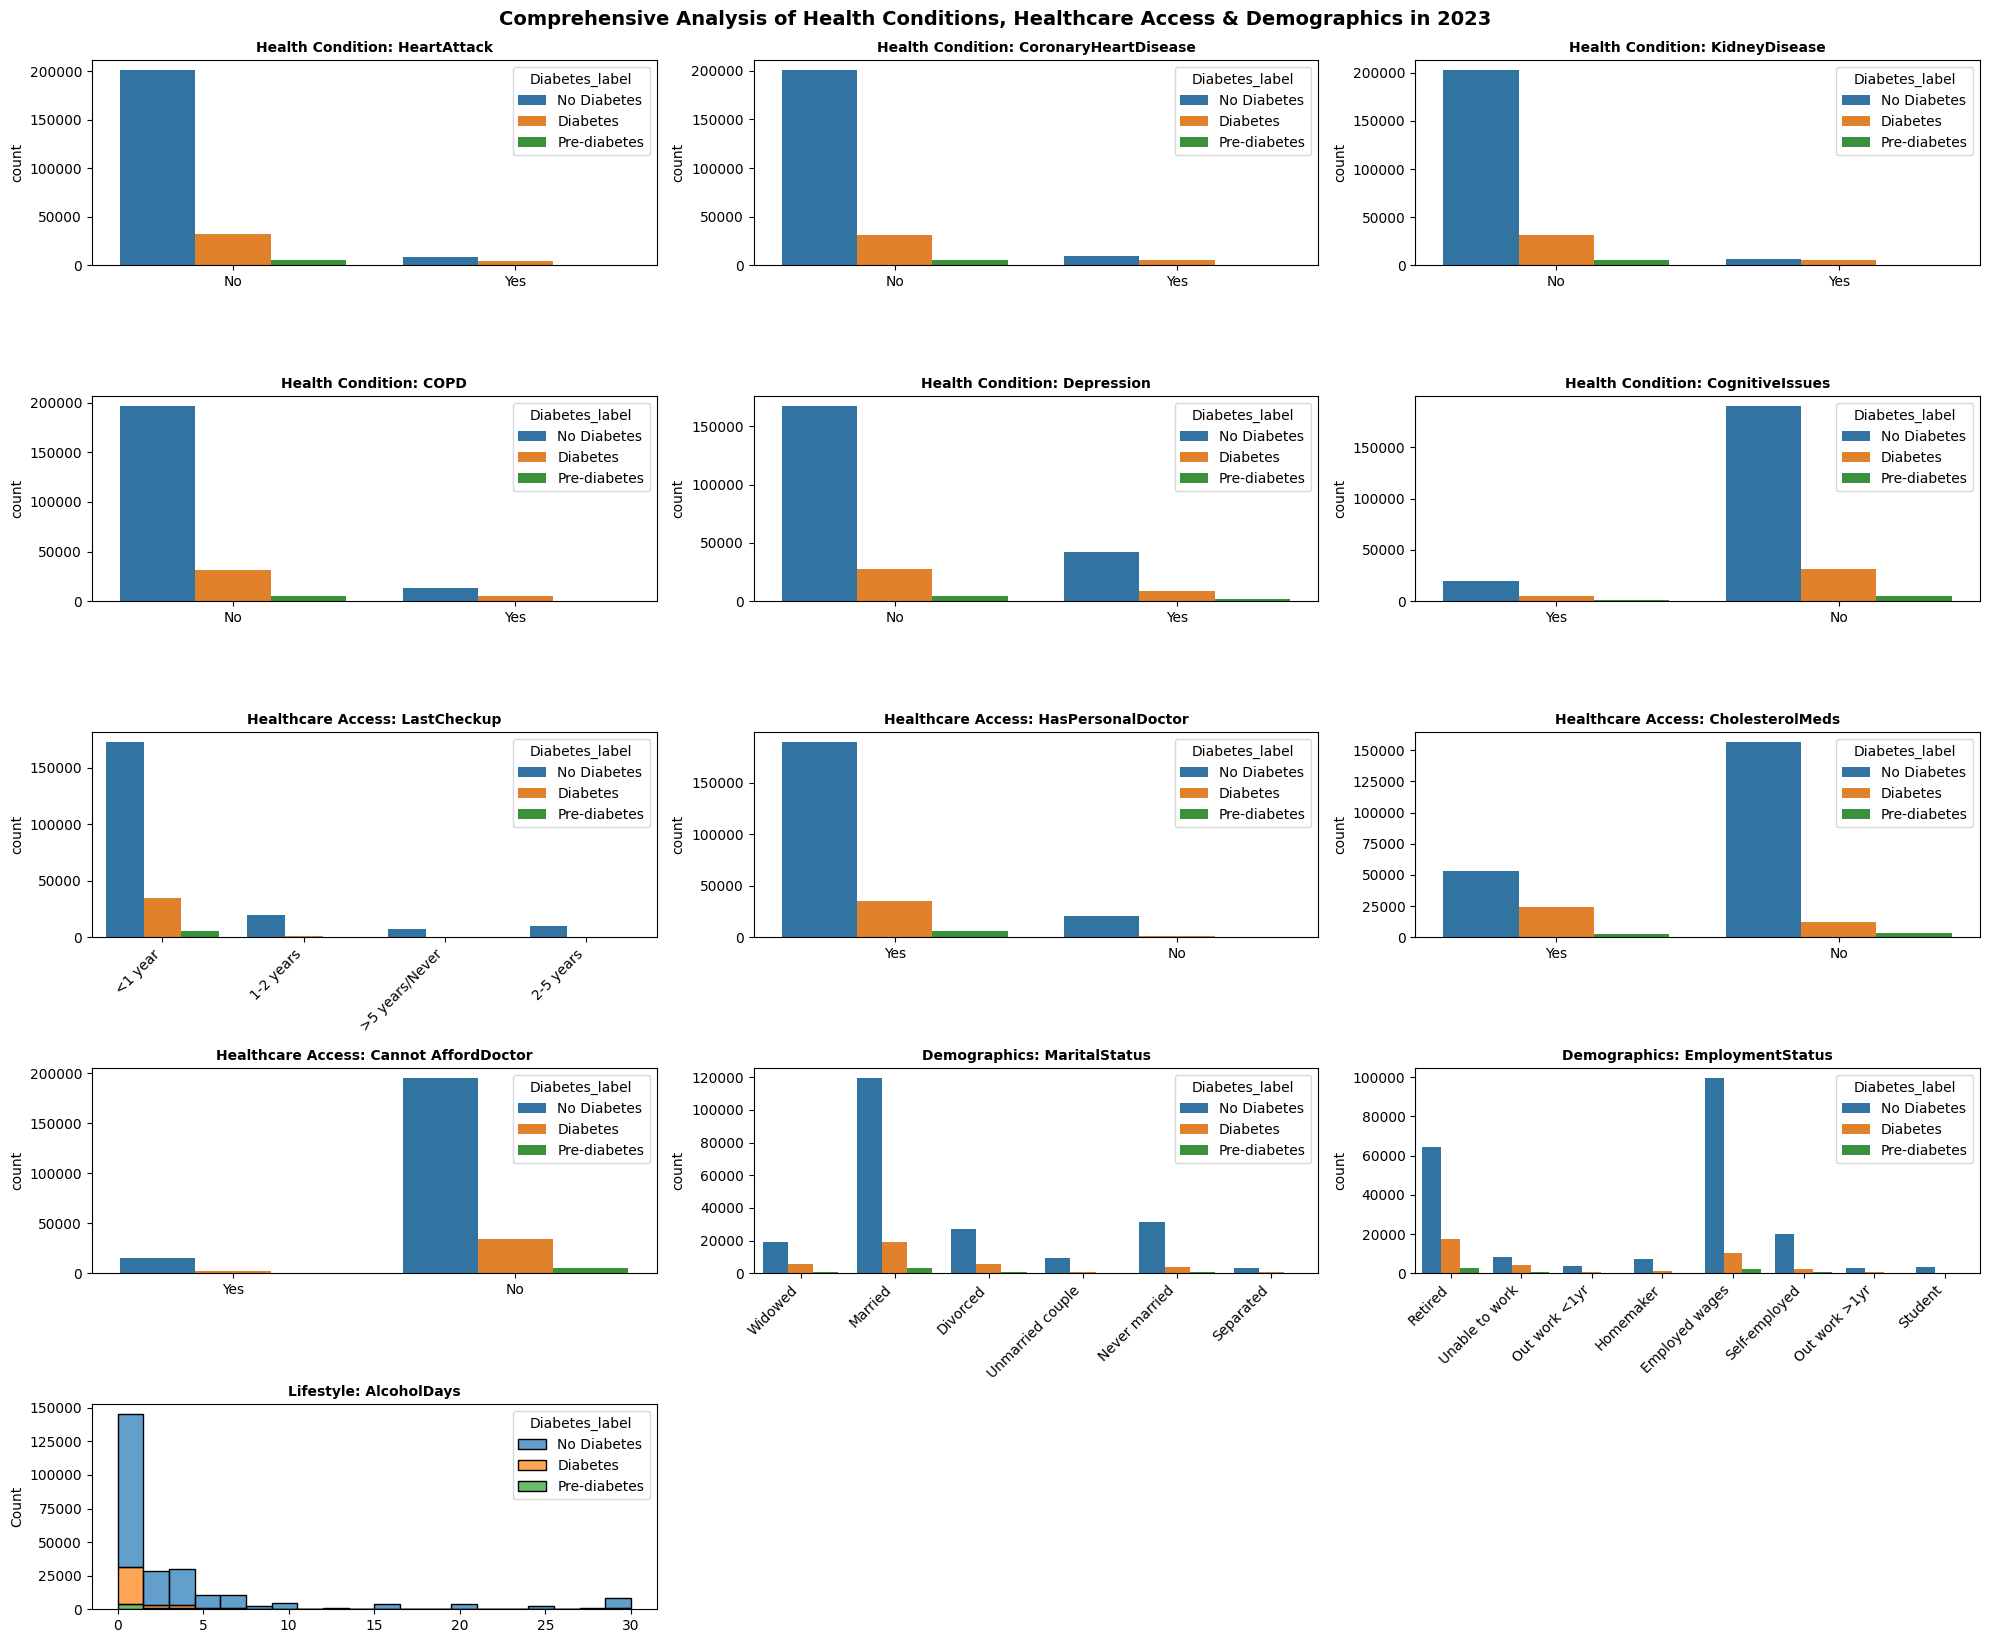

In [13]:
plot_additional_features_analysis(df=cleaned_df, year=2023)

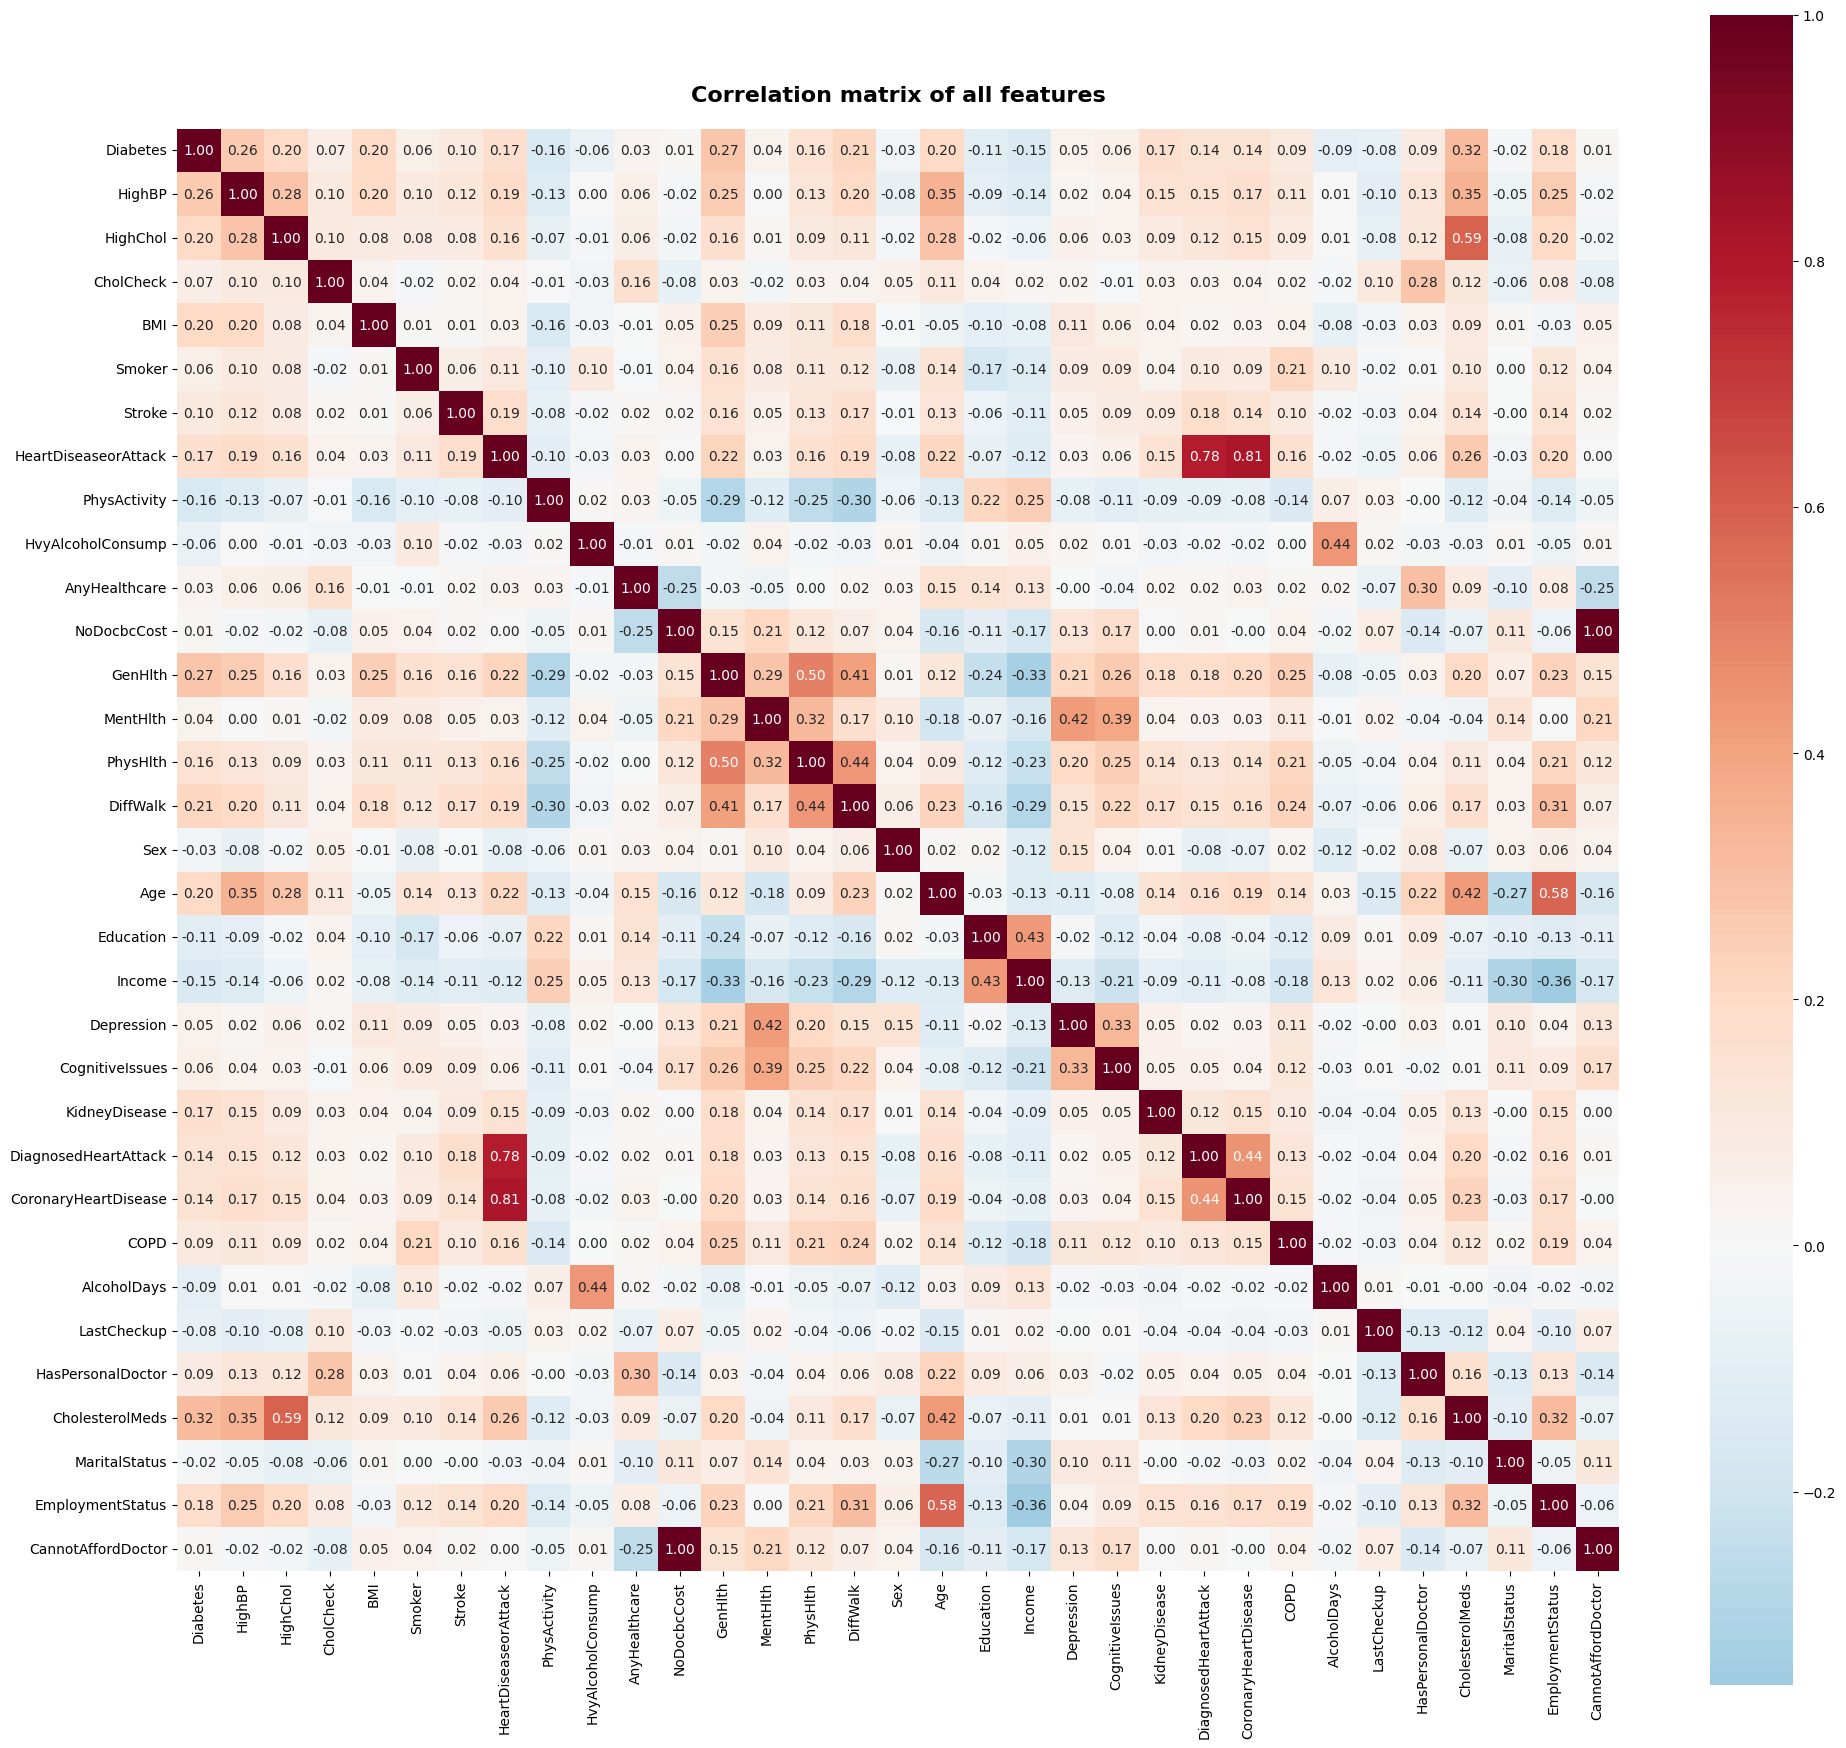

In [14]:
# Display correlation heatmap
plot_correlation_matrix(
    df=cleaned_df,
    title="Correlation matrix of all features"
)

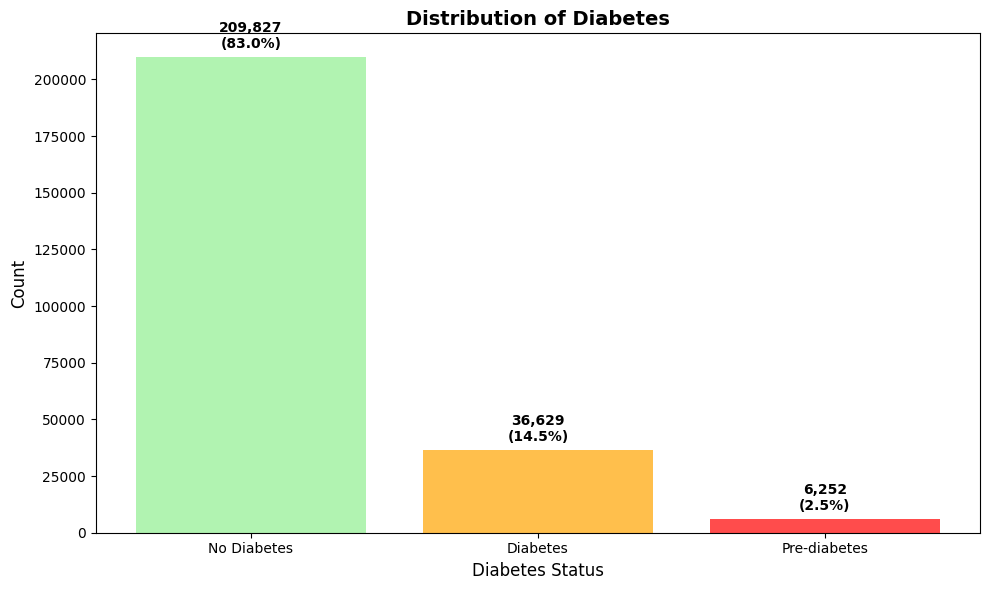

In [15]:
# Plot distribution of classes in the dataset
plot_class_distribution(
    y=cleaned_df["Diabetes"],
    title="Distribution of Diabetes"
)

## **3. Feature engineering**

**What was accomplished:**
- Applied pre-trained feature selection (21 selected features from original dataset)
- Implemented consistent encoding using pre-trained encoders from historical data
- Maintained feature engineering consistency across time periods
- Ensured proper data preprocessing for model inference

**Results achieved:**
- Successfully transformed raw 2023 data into model-ready format
- Preserved feature relationships learned from training data
- Maintained data quality and feature importance rankings

In [16]:
# Get selected features and encoders of 2017, 2019, 2021
selected_features = load_data(f"{TRAINING_DIR}/selected_features.pkl")
encoders = load_data(f"{TRAINING_DIR}/encoders.pkl")

# Apply a complete feature engineering pipeline
diabetes_feature_engineering = DiabetesFeatureEngineering(
    logger_name="data_pipeline.feature_engineering", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
processed_df = diabetes_feature_engineering.process_for_inference(
    df=cleaned_df,
    selected_features=selected_features,
    encoders=encoders
)

2025-09-28 15:03:25,087 - [data_pipeline.feature_engineering] - INFO - Enhanced DiabetesFeatureEngineering initialized successfully
2025-09-28 15:03:25,088 - [data_pipeline.feature_engineering] - INFO - ================================================================================
2025-09-28 15:03:25,089 - [data_pipeline.feature_engineering] - INFO - STARTING ENHANCED INFERENCE FEATURE ENGINEERING PIPELINE
2025-09-28 15:03:25,089 - [data_pipeline.feature_engineering] - INFO - ================================================================================
2025-09-28 15:03:25,090 - [data_pipeline.feature_engineering] - INFO - Initial dataset shape: (252708, 37)
2025-09-28 15:03:25,091 - [data_pipeline.feature_engineering] - INFO - Starting null values removal process...
2025-09-28 15:03:25,142 - [data_pipeline.feature_engineering] - INFO - No null values found in the dataset
2025-09-28 15:03:25,245 - [data_pipeline.feature_engineering] - INFO - Null values removal completed. Removed 0

In [17]:
# Display the first five rows in the dataset
processed_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,...,HasPersonalDoctor,CholesterolMeds,EmploymentStatus,HlthScore,RiskScore,LifestyleScore,CardioRisk,CholesterolManagementScore,MentalHealthScore,Diabetes
2,1.0,1.0,1.0,22.0,1.0,0.0,0.0,1.0,0.0,4.0,...,1.0,1.0,7.0,1.566667,2.0,0.000000,2.0,1.5,-1.066667,0.0
4,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,4.0,...,1.0,0.0,8.0,1.300000,1.0,0.933333,1.0,1.0,-2.000000,2.0
5,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,0.0,3.0,...,1.0,0.0,7.0,0.766667,2.0,0.833333,2.0,0.0,-0.100000,0.0
8,1.0,1.0,1.0,33.0,0.0,0.0,0.0,0.0,0.0,3.0,...,1.0,1.0,7.0,1.266667,3.0,0.000000,3.0,1.5,0.000000,0.0
9,1.0,1.0,1.0,23.0,1.0,0.0,1.0,1.0,0.0,3.0,...,1.0,1.0,7.0,0.600000,5.0,0.000000,4.0,1.5,0.000000,2.0


In [18]:
# Display overall about dataset
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 251130 entries, 2 to 433321
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   HighBP                      251130 non-null  float64
 1   HighChol                    251130 non-null  float64
 2   CholCheck                   251130 non-null  float64
 3   BMI                         251130 non-null  float64
 4   Smoker                      251130 non-null  float64
 5   Stroke                      251130 non-null  float64
 6   HeartDiseaseorAttack        251130 non-null  float64
 7   PhysActivity                251130 non-null  float64
 8   HvyAlcoholConsump           251130 non-null  float64
 9   GenHlth                     251130 non-null  float64
 10  MentHlth                    251130 non-null  float64
 11  PhysHlth                    251130 non-null  float64
 12  DiffWalk                    251130 non-null  float64
 13  Age                

## **4. Data preparation**

In [19]:
# Separate features (X) and target variable (y) for model training
X, y = processed_df.drop("Diabetes", axis=1), processed_df["Diabetes"]

In [20]:
# Load pretrained Min-Max scaler
tomek_scaler = load_data(path=BEST_ACCURACY_MODEL_SCALER_FILE_PATH)
ros_scaler = load_data(path=BEST_F1_MODEL_SCALER_FILE_PATH)
rus_scaler = load_data(path=BEST_RECALL_MODEL_SCALER_FILE_PATH)

In [21]:
def normalize_data(scaler, X):
    X_test_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)
    return X_test_scaled

In [22]:
# Normalize features
tomek_X = normalize_data(tomek_scaler, X)
ros_X = normalize_data(ros_scaler, X)
rus_X = normalize_data(rus_scaler, X)

## **5. Load pretrained models**

In [23]:
# Initialize models
best_acc_xgb_model = DiabetesXGBoostClassifier(
    logger_name="models.best_acc_xgboost", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
best_f1_xgb_model = DiabetesXGBoostClassifier(
    logger_name="models.best_f1_xgboost", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
best_recall_random_forest_model = DiabetesRandomForest(
    logger_name="models.best_recall_random_forest", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)
best_pre_xgb_model = DiabetesXGBoostClassifier(
    logger_name="models.best_prec_xgboost", 
    log_file=f"{LOG_DIR}/6_diabetes_2023_prediction.log"
)

# Load pretrained models
best_acc_xgb_model.load_model(model_path=BEST_ACCURACY_MODEL_FILE_PATH)
best_f1_xgb_model.load_model(model_path=BEST_F1_MODEL_FILE_PATH)
best_recall_random_forest_model.load_model(model_path=BEST_RECALL_MODEL_FILE_PATH)
best_pre_xgb_model.load_model(model_path=BEST_PRECISION_MODEL_FILE_PATH)

2025-09-28 15:03:28,460 - [models.best_acc_xgboost] - INFO - DiabetesXGBoostClassifier initialized with parameters:
2025-09-28 15:03:28,463 - [models.best_acc_xgboost] - INFO -  n_estimators: 100
2025-09-28 15:03:28,465 - [models.best_acc_xgboost] - INFO -  max_depth: 6
2025-09-28 15:03:28,468 - [models.best_acc_xgboost] - INFO -  learning_rate: 0.1
2025-09-28 15:03:28,469 - [models.best_acc_xgboost] - INFO -  subsample: 1.0
2025-09-28 15:03:28,470 - [models.best_acc_xgboost] - INFO -  colsample_bytree: 1.0
2025-09-28 15:03:28,472 - [models.best_acc_xgboost] - INFO -  random_state: 42
2025-09-28 15:03:28,474 - [models.best_f1_xgboost] - INFO - DiabetesXGBoostClassifier initialized with parameters:
2025-09-28 15:03:28,475 - [models.best_f1_xgboost] - INFO -  n_estimators: 100
2025-09-28 15:03:28,476 - [models.best_f1_xgboost] - INFO -  max_depth: 6
2025-09-28 15:03:28,477 - [models.best_f1_xgboost] - INFO -  learning_rate: 0.1
2025-09-28 15:03:28,479 - [models.best_f1_xgboost] - INFO - 

In [24]:
# The parameters of best accuracy XGBoost model
best_acc_xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '.../artifacts/models/best_accuracy_model.pkl'}

In [25]:
# The parameters of best F1 XGBoost model
best_f1_xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '.../artifacts/models/best_f1_model.pkl'}

In [26]:
# The parameters of best recall Random Forest model
best_recall_random_forest_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 25,
 'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'random_state': 42,
 'model_path': '.../artifacts/models/best_recall_model.pkl',
 'n_features': 33,
 'n_classes': 3}

In [27]:
# The parameters of best precision XGBoost model
best_pre_xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '.../artifacts/models/best_precision_model.pkl'}

## **6. Diabetes prediction**

### **6.1 XGBoost model with Tomek Links data**

In [28]:
# Predict with best accuracy model with Tomek Links data
best_acc_y_pred = best_acc_xgb_model.predict(X=tomek_X)

2025-09-28 15:03:29,694 - [models.best_acc_xgboost] - INFO - Predictions made for 251130 samples


In [29]:
# Evaluation
best_acc_xgb_model.evaluate(y_true=y, y_pred=best_acc_y_pred)

2025-09-28 15:03:29,819 - [models.best_acc_xgboost] - INFO - Model Evaluation Results:
2025-09-28 15:03:29,820 - [models.best_acc_xgboost] - INFO - Accuracy: 0.6950
2025-09-28 15:03:29,821 - [models.best_acc_xgboost] - INFO - Precision: 0.4143
2025-09-28 15:03:29,823 - [models.best_acc_xgboost] - INFO - Recall: 0.4655
2025-09-28 15:03:29,824 - [models.best_acc_xgboost] - INFO - F1-Score: 0.4241


2025-09-28 15:03:29,939 - [models.best_acc_xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.76      0.81    208308
         1.0       0.08      0.21      0.12      6251
         2.0       0.28      0.43      0.34     36571

    accuracy                           0.69    251130
   macro avg       0.41      0.47      0.42    251130
weighted avg       0.77      0.69      0.73    251130

2025-09-28 15:03:30,120 - [models.best_acc_xgboost] - INFO - Confusion Matrix:
[[157374  12196  38738]
 [  3605   1296   1350]
 [ 18404   2308  15859]]


{'accuracy': 0.6949747142914029,
 'precision': 0.41426574609949385,
 'recall': 0.46548783600544835,
 'f1_score': 0.42407633741626327}

### **6.2 XGBoost model with Random Oversampling data**

In [30]:
# Predict with best F1 score model with Random Oversampling data
best_f1_y_pred = best_f1_xgb_model.predict(X=ros_X)

2025-09-28 15:03:30,849 - [models.best_f1_xgboost] - INFO - Predictions made for 251130 samples


In [31]:
# Evaluation
best_f1_xgb_model.evaluate(y_true=y, y_pred=best_f1_y_pred)

2025-09-28 15:03:30,982 - [models.best_f1_xgboost] - INFO - Model Evaluation Results:
2025-09-28 15:03:30,984 - [models.best_f1_xgboost] - INFO - Accuracy: 0.6893
2025-09-28 15:03:30,985 - [models.best_f1_xgboost] - INFO - Precision: 0.4382
2025-09-28 15:03:30,986 - [models.best_f1_xgboost] - INFO - Recall: 0.5025
2025-09-28 15:03:30,987 - [models.best_f1_xgboost] - INFO - F1-Score: 0.4400


2025-09-28 15:03:31,117 - [models.best_f1_xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.74      0.81    208308
         1.0       0.06      0.28      0.10      6251
         2.0       0.36      0.49      0.41     36571

    accuracy                           0.69    251130
   macro avg       0.44      0.50      0.44    251130
weighted avg       0.80      0.69      0.73    251130

2025-09-28 15:03:31,325 - [models.best_f1_xgboost] - INFO - Confusion Matrix:
[[153557  24607  30144]
 [  3154   1776   1321]
 [ 14860   3933  17778]]


{'accuracy': 0.6893282363716003,
 'precision': 0.43820480844535376,
 'recall': 0.5024668883252502,
 'f1_score': 0.43997563816500956}

### **6.3 Random Forest model with Random Undersampling data**

In [32]:
# Predict with best recall model with Random Undersampling data
best_recall_y_pred = best_recall_random_forest_model.predict(X=rus_X)

2025-09-28 15:03:38,361 - [models.best_recall_random_forest] - INFO - Predictions made for 251130 samples


In [33]:
# Evaluation
best_recall_random_forest_model.evaluate(y_true=y, y_pred=best_recall_y_pred)

2025-09-28 15:03:38,503 - [models.best_recall_random_forest] - INFO - Model Evaluation Results:
2025-09-28 15:03:38,504 - [models.best_recall_random_forest] - INFO - Accuracy: 0.6488
2025-09-28 15:03:38,506 - [models.best_recall_random_forest] - INFO - Precision: 0.4465
2025-09-28 15:03:38,507 - [models.best_recall_random_forest] - INFO - Recall: 0.5455
2025-09-28 15:03:38,508 - [models.best_recall_random_forest] - INFO - F1-Score: 0.4416
2025-09-28 15:03:38,651 - [models.best_recall_random_forest] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.66      0.77    208308
         1.0       0.06      0.32      0.10      6251
         2.0       0.35      0.66      0.46     36571

    accuracy                           0.65    251130
   macro avg       0.45      0.55      0.44    251130
weighted avg       0.83      0.65      0.71    251130

2025-09-28 15:03:38,794 - [models.best_recall_random_forest] - INFO - Confusion Mat

{'accuracy': 0.6488073905945128,
 'precision': 0.4464558552544678,
 'recall': 0.5454875438446525,
 'f1_score': 0.44162513272570164}

### **6.4 XBGBoost with Tomek Links data**

In [34]:
# Predict with best precision model with Tomek Links data
best_pre_y_pred = best_pre_xgb_model.predict(X=tomek_X)

2025-09-28 15:03:39,312 - [models.best_prec_xgboost] - INFO - Predictions made for 251130 samples


In [35]:
# Evaluation
best_pre_xgb_model.evaluate(y_true=y, y_pred=best_pre_y_pred)

2025-09-28 15:03:39,432 - [models.best_prec_xgboost] - INFO - Model Evaluation Results:
2025-09-28 15:03:39,433 - [models.best_prec_xgboost] - INFO - Accuracy: 0.6950
2025-09-28 15:03:39,434 - [models.best_prec_xgboost] - INFO - Precision: 0.4143
2025-09-28 15:03:39,435 - [models.best_prec_xgboost] - INFO - Recall: 0.4655
2025-09-28 15:03:39,436 - [models.best_prec_xgboost] - INFO - F1-Score: 0.4241
2025-09-28 15:03:39,537 - [models.best_prec_xgboost] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.76      0.81    208308
         1.0       0.08      0.21      0.12      6251
         2.0       0.28      0.43      0.34     36571

    accuracy                           0.69    251130
   macro avg       0.41      0.47      0.42    251130
weighted avg       0.77      0.69      0.73    251130

2025-09-28 15:03:39,672 - [models.best_prec_xgboost] - INFO - Confusion Matrix:
[[157374  12196  38738]
 [  3605   1296   1350]
 [ 

{'accuracy': 0.6949747142914029,
 'precision': 0.41426574609949385,
 'recall': 0.46548783600544835,
 'f1_score': 0.42407633741626327}